## SGD·학습률·초기화 비교 실험

### 경사하강법의 업데이트식

훈련할 모델의 목적은 손실 함수 $L(\theta)$를 최소화하는 것이다.

- $\theta$: 모델이 학습해야 할 모든 파라미터

- $L(\theta)$: 현재 파라미터가 얼마나 좋지 않은지를 나타내는 손실(loss)

- $\nabla_\theta L$: 손실이 가장 빠르게 증가하는 방향(Gradient)

- $\eta$: 한 번에 이동하는 크기, 즉 학습률(Learning Rate)

파라미터는 손실이 **감소하는 방향**으로 업데이트되므로, 업데이트 식은 다음과 같음

$$
\theta_{\text{new}}
=
\theta_{\text{old}}
-
\eta \nabla_\theta L
$$

여기서 가장 중요한 부분은 마이너스 기호이다.

gradient는 손실이 증가하는 방향을 가리키므로, 손실을 줄이려면 그 반대 방향으로 이동해야 한다


### 예시

손실 함수가 다음과 같다고 하자

$$
L(w)=(w-3)^2
$$

이 함수는 $w=3$일 때 최소가 된다

미분하면:

$$
\frac{dL}{dw}=2(w-3)
$$

현재 값이 $w=0$, 학습률이 $\eta=0.1$이라면:

$$
\frac{dL}{dw}=2(0-3)=-6
$$

업데이트하면:

$$
w_{\text{new}}
=
0-0.1(-6)
=
0.6
$$

즉, $w$가 $0$에서 최솟값인 $3$ 방향으로 이동했다.

손실도 확인해보자

$$
L(0)=9
$$

$$
L(0.6)=5.76
$$

한 번의 업데이트로 손실이 $9$에서 $5.76$으로 감소했다.


### 학습률이 결정하는 것이란?

같은 $gradient = -6$에서도 학습률에 따라 이동 거리가 달라진다.

| 학습률 $\eta$ | 새로운 $w$ | 해석 |
|:------------:|:----------:|:-----|
| $0.01$ | $0.06$ | 안전하지만 매우 작은 이동 |
| $0.1$ | $0.6$ | 비교적 적절한 이동 |
| $1.0$ | $6.0$ | 최솟값을 크게 지나침 |
| $2.0$ | $12.0$ | 최솟값에서 더 멀어짐 |

<br>

즉, 중요한 점은 **큰 학습률이 항상 빠른 것은 아니다**라는 것

* 너무 작으면 손실이 천천히 감소한다

* 적절하면 빠르고 안정적으로 수렴한다

* 너무 크면 최솟값 주변을 왕복한다

* 더 크면 손실이 계속 증가하며 발산할 수 있다

### GD와 SGD의 차이

데이터 10000개가 있다고 가정하자.

<br>

**Full-batch Gradient Descent**

10,000개 전체의 평균 gradient를 계산한 뒤 한 번 업데이트한다.
$$
g=
\frac{1}{10000}
\sum_{i=1}^{10000}\nabla_\theta L_i
$$

* 방향이 안정적이다 - 개별 데이터 때문에 생기는 우연한 차이가 상쇄되어, "전체 데이터를 가장 잘 줄여주는 방향"을 알려준다.

* 업데이트 한 번의 계산량이 크다

* 같은 파라미터에서 전체 데이터를 봐야 한다

* 평균을 내서 각 데이터의 노이즈가 사라지게 된다

<br>

**Stochastic Gradient Descent**

원래 의미의 SGD는 샘플 하나로 gradient를 계산한다
$$g=\nabla_\theta L_i$$

* 업데이트가 빠르고 자주 일어난다 - 데이터 한 개만 사용해서 기울기를 계산하기에

* 각 샘플의 특성 때문에, 방향이 자주 흔들린다 - 샘플 하나하나마다 다 다른 특징이 있을 수 있기에

* 손실이 매끄럽게 감소하지 않을 수도 있다 - 샘플 하나 때문에 방향이 계속 달라지기 때문에

<br>

**Mini-batch SGD**

실무에서는 보통 32개나 64개 같은 작은 묶음을 사용한다
$$
g=
\frac{1}{B}
\sum_{i\in\text{batch}}\nabla_\theta L_i
$$

* full-batch와 SGD의 중간 방식

* full-batch보다 계산이 효율적이다 - 32개를 묶어서 계산해서 바로바로 업데이트 가능 (중간중간)

* 샘플 하나(SGD)보다 gradient가 안정적이다 - 샘플 하나는 데이터의 특성을 제대로 대표하지 못할 수 있음

* 우리가 흔히 “SGD로 학습한다”고 할 때 대개 이 방식을 의미한다 - 대부분 미니 배치를 사용하기 때문이다

방법

1. 데이터 32개의 gradient를 계산한다

2. 32개의 gradient의 평균을 구한다

3. 그 평균으로 파라미터를 한 번 업데이트한다

4. 다음 32개 데이터를 가져와 반복한다 (즉 묶어서 계산한다)

다만,

- mini-batch의 gradient는 전체 데이터 gradient의 정확한 값이 아니라 추정치다.


그래서 loss curve에는 흔들림이 생긴다. 이 흔들림이 반드시 버그를 의미하지는 않는다.

## 실험 환경의 구성

### 실험 해야할 것

1. 학습률이 학습 결과에 어떤 영향을 주는가?

2. 초기화가 학습 결과에 어떤 영향을 주는가?

이를 정확히 알아보려면, 한 번에 하나의 조건만 바꿔야 한다

예를 들어 학습률을 비교하면서 초기 가중치까지 매번 달라진다면, 결과 차이가 학습률 때문인지 초기화 때문인지 판단할 수 없다

<br>

### 통제할 조건

학습률 비교에서는 다음을 모두 동일하게 유지한다

* 학습 데이터

* 모델 구조

* 초기 가중치

* epoch 수

* batch 순서

* 손실 함수

* 초기화 방법

그리고 learning rate만 변경한다

<br>

초기화 비교에서는 다음을 모두 동일하게 유지한다

* 학습 데이터

* 모델 구조

* learning rate

* epoch 수

* batch 순서

그리고 초기화 방법만 변경한다

<br>

### 난수 시드의 의미

다음 두 코드는 서로 다른 결과를 만들 수 있다

```python
rng = np.random.default_rng()
W1 = rng.standard_normal((2, 8))
```
<br>

시드를 고정하면 실행할 때마다 같은 난수가 나온다

<br>

```python
rng = np.random.default_rng(42)
W1 = rng.standard_normal((2, 8))
```

이것을 재현성이라고 한다

<br>

### **추가 설명**

난수는 사실 완전히 무작위가 아니라, 시작점(seed)으로부터 만들어지는 의사난수(pseudorandom number)라는 점부터 시작하는 것이다

의사난수는 시드(seed)라는 시작값을 바탕으로 일정한 규칙에 따라 만들어지는 숫자들의 순서이다

예를 들어 ```rng = np.random.default_rng(42)```라고 하면 난수 생성기의 시작점을 42로 정하는 것이다

그러면 이후 생성되는 난수는 항상 같은 순서가 된다

```python
rng = np.random.default_rng(42)

print(rng.standard_normal())
print(rng.standard_normal())
print(rng.standard_normal())
```

```
0.3047...
-1.0399...
0.7504...
```

```rng = np.random.default_rng()```처럼 시드를 주지 않으면 NumPy가 여러 정보를 이용해 매번 다른 시드를 선택한다

시드를 고정하면

- 항상 같은 초기 가중치가 만들어지고

- 학습 결과도 같은 조건에서 시작하게 된다

그래서 실험 결과를 다시 확인하거나 다른 사람과 동일한 실험을 수행하기가 쉬워지기에, 이를 재현성(reproducibility)이라고 하는 것이다

### **주의할 점**

시드는 같은 난수 하나를 만드는 것이 아니라, 난수의 순서(sequence)를 결정한다는 점을 주의해야 한다.

같은 시드에서 시작하지만, 난수는 계속 소비된다

```python
rng = np.random.default_rng(42)

W_small = rng.standard_normal((2, 8))
W_medium = rng.standard_normal((2, 8))
```

- 두 배열은 같은 시드에서 출발했지만 서로 다른 난수를 사용한다

- 따라서 초기화 크기를 공정하게 비교하려면 먼저 하나의 기준 배열을 만들고 배율만 바꾸는 편이 좋다

<br>

```python
base_W = rng.standard_normal((2, 8))

W_small = base_W * 0.01
W_medium = base_W * 1.0
W_large = base_W * 10.0
```

세 배열의 방향과 부호는 같고, 크기만 다르다고 볼 수 있다

<br>

비유하면, 시드를 책의 첫 페이지라고 생각하면 쉬울듯?

seed = 42 -> 항상 1페이지에서 책을 읽기 시작한다

W_small -> 1~16페이지를 읽는다

W_medium -> 이어서 17~32페이지를 읽는다

매번 같은 책을 같은 페이지부터 읽기 때문에 재현성은 유지되지만, 이미 읽은 페이지를 다시 읽는 것은 아니므로 서로 다르다고 볼 수 있다.

X shape: (400, 2)
y shape: (400, 1)
class 0: 200
class 1: 200


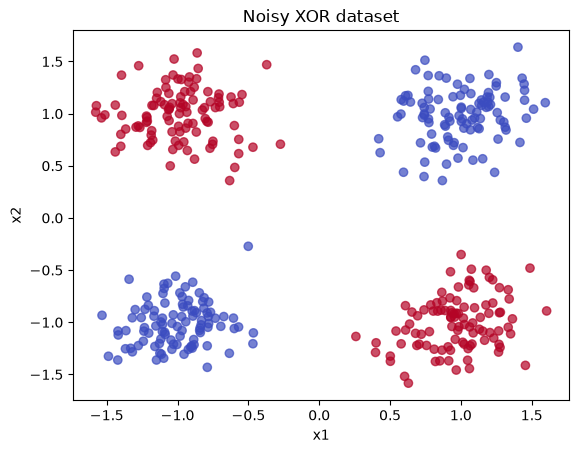

In [62]:
import numpy as np
import matplotlib.pyplot as plt

DATA_SEED = 42
rng = np.random.default_rng(DATA_SEED)  # 난수를 만들어 주는 객체를 생성

centers = np.array([
    [-1.0, -1.0],
    [-1.0,  1.0],
    [ 1.0, -1.0],
    [ 1.0,  1.0],
])

center_labels = np.array([0, 1, 1, 0])

samples_per_center = 100
noise_std = 0.25

X_parts = []
y_parts = []

for center, label in zip(centers, center_labels):
    points = center + rng.normal(
        loc=0.0, # 평균
        scale=noise_std, # 표준편차
        size=(samples_per_center, 2), # 출력 크기
    ) # 평균이 0, 표준편차가 nosie_std인 난수를 (100,2) 크기로 만들어라 (정규분포 난수 생성)

    labels = np.full(
        (samples_per_center, 1), # shape
        label, # fill_value
        dtype=float,
    ) # 같은 값으로 배열 생성

    X_parts.append(points)
    y_parts.append(labels)

X = np.vstack(X_parts)
y = np.vstack(y_parts)

# np.vstack(): vertical stack의 줄임말로 배열을 row대로 쌓는다 (데이터 값 쌓기)
# np.hstack(): horizontal stack의 줄임말로 배열을 column대로 쌓는다

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class 0:", np.sum(y == 0))
print("class 1:", np.sum(y == 1))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y.ravel(),
    cmap="coolwarm",
    alpha=0.7,
)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Noisy XOR dataset")
plt.show()

이전에 배웠듯이, XOR 분류는 단일 선형 분류로는 불가능하고 은닉층과 활성화함수가 필요하다

### 훈련용 데이터와 검증용 데이터의 분할

데이터를 두 부분으로 나눠야 한다

* 훈련 데이터: gradient를 계산하고 파라미터를 업데이트

* 검증 데이터: 학습에 참여하지 않고 일반화 성능만 측정

같은 데이터로 학습과 평가를 모두 하면 모델이 데이터를 이해한 것인지 단순히 외운 것인지 구분하기 어렵다

In [63]:
SPLIT_SEED = 123
split_rng = np.random.default_rng(SPLIT_SEED)

indices = split_rng.permutation(len(X))
# permutation(n): 0부터 n-1까지의 숫자를 랜덤하게 섞어서 반환하는 매서드

split_index = int(len(X) * 0.8)

train_indices = indices[:split_index]
val_indices = indices[split_index:]

# 데이터를 분할한다. 랜덤으로 돌려서 80%는 학습용, 20%는 검증용으로

X_train = X[train_indices]
y_train = y[train_indices]

X_val = X[val_indices]
y_val = y[val_indices]

# 인덱싱을 활용해서, 랜덤으로 섞인 인덱스의 값들을 train 데이터에 각각 박는다

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("train class 1 ratio:", y_train.mean())
print("val class 1 ratio:", y_val.mean())

X_train: (320, 2)
y_train: (320, 1)
X_val: (80, 2)
y_val: (80, 1)
train class 1 ratio: 0.490625
val class 1 ratio: 0.5375


In [64]:
def initialize_parameters(
    input_dim=2,
    hidden_dim=8,
    output_dim=1,
    seed=42,
    weight_scale=0.1,
):
    rng = np.random.default_rng(seed)

    parameters = {
        "W1": rng.standard_normal(
            (input_dim, hidden_dim)
        ) * weight_scale,

        "b1": np.zeros((1, hidden_dim)),

        "W2": rng.standard_normal(
            (hidden_dim, output_dim)
        ) * weight_scale,

        "b2": np.zeros((1, output_dim)),
    }

    return parameters

동일한 시드가 동일한 초기값을 만드는지 검증한다

In [65]:
params_a = initialize_parameters(seed=42)
params_b = initialize_parameters(seed=42)
params_c = initialize_parameters(seed=99)

print(
    "same seed:",
    np.array_equal(params_a["W1"], params_b["W1"])
)

print(
    "different seed:",
    np.array_equal(params_a["W1"], params_c["W1"])
)

for name, value in params_a.items():
    print(
        name,
        "shape =", value.shape,
        "mean =", value.mean(),
        "std =", value.std(),
    )

same seed: True
different seed: False
W1 shape = (2, 8) mean = -0.0056064649366805025 std = 0.08849003282005509
b1 shape = (1, 8) mean = 0.0 std = 0.0
W2 shape = (8, 1) mean = 0.005507656527881821 std = 0.06911637749602509
b2 shape = (1, 1) mean = 0.0 std = 0.0


매 실험에서 seed=42로 초기화하는 목적?

1. 실험을 다시 실행해도 같은 결과를 얻는 재현성

2. 학습률마다 완전히 같은 가중치에서 출발하게 하는 통제

### 중간점검

기존에는 내가 쓴 코드와, 내가 쓴 구조를 통한 LLM이 짜준 코드가 혼재했는데 이러니까 내 코드 구현 능력이 떨어지는 기분이 들었음

일단은 이 뒤로는 스스로 코드를 전부 짜보는 연습을 해보려고 함

In [66]:
def forward(X, parameters):
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]

    Z1 = X @ W1 + b1
    A1 = np.maximum(0, Z1)
    Z2 = A1 @ W2 + b2
    Z2_safe = np.clip(Z2, -50, 50)
    Y_hat = 1 / (1 + np.exp(-Z2_safe))

    cache = {
        "Z1":Z1, "A1":A1, "Z2":Z2, "Y_hat":Y_hat
    }

    return Y_hat, cache


In [67]:
parameters = initialize_parameters(seed=42)

Y_hat, cache = forward(X_train, parameters)

assert Y_hat.shape == (320, 1)
assert cache["Z1"].shape == (320, 8)
assert cache["A1"].shape == (320, 8)
assert cache["Z2"].shape == (320, 1)

assert np.all(Y_hat >= 0)
assert np.all(Y_hat <= 1)
assert np.all(cache["A1"] >= 0)
assert np.all(np.isfinite(Y_hat))

print("Y_hat shape:", Y_hat.shape)
print("Y_hat min:", Y_hat.min())
print("Y_hat max:", Y_hat.max())
print("활성화된 ReLU 비율:", np.mean(cache["A1"] > 0))
print("순전파 테스트 통과")

Y_hat shape: (320, 1)
Y_hat min: 0.4908124604974992
Y_hat max: 0.5083734114826879
활성화된 ReLU 비율: 0.5015625
순전파 테스트 통과


LLM이 만들어준 테스트기로, 내 코드를 검증해보았음. 앞으로도 이런 방식으로 학습할 예정

### BCE Loss 함수 구현

In [68]:
def compute_loss(Y_hat, y):
    epsilon = 1e-12
    Y_hat_safe = np.clip(Y_hat, -epsilon, epsilon)

    loss = -np.mean(y * np.log(Y_hat_safe) + (1 - y) * np.log(1 - Y_hat_safe))

    return loss

In [69]:
parameters = initialize_parameters(seed=42)
Y_hat, cache = forward(X_train, parameters)

loss = compute_loss(Y_hat, y_train)

assert np.ndim(loss) == 0
assert np.isfinite(loss)
assert loss >= 0

print("initial loss:", loss)

initial loss: 13.556469735002953


엥 뭔가 문제가 생겼다... 어디가 틀렸는지 고쳐야한다 -> epslion 부분을 잘못썼구나!

### 수정코드

In [70]:
def compute_loss(Y_hat, y):
    epsilon = 1e-12
    Y_hat_safe = np.clip(Y_hat, epsilon, 1 - epsilon)

    loss = -np.mean(y * np.log(Y_hat_safe) + (1 - y) * np.log(1 - Y_hat_safe))

    return loss

In [71]:
parameters = initialize_parameters(seed=42)
Y_hat, cache = forward(X_train, parameters)

loss = compute_loss(Y_hat, y_train)

assert np.ndim(loss) == 0
assert np.isfinite(loss)
assert loss >= 0

print("initial loss:", loss)

initial loss: 0.6949929594590775


Loss Test

In [72]:
y_test = np.array([[0.0], [1.0]])

good_predictions = np.array([[0.01], [0.99]])
bad_predictions = np.array([[0.99], [0.01]])

good_loss = compute_loss(good_predictions, y_test)
bad_loss = compute_loss(bad_predictions, y_test)

print("good loss:", good_loss)
print("bad loss:", bad_loss)

assert good_loss < bad_loss
print("BCE 테스트 통과")

good loss: 0.01005033585350145
bad loss: 4.605170185988091
BCE 테스트 통과


### 역전파 구현

In [73]:
def backward(X, y, parameters, cache):
    N = X.shape[0]

    W2 = parameters["W2"]

    Z1 = cache["Z1"]
    A1 = cache["A1"]
    Y_hat = cache["Y_hat"]

    # BCE + sigmoid의 출력층 gradient
    dZ2 = (Y_hat - y) / N

    # 출력층 파라미터 gradient
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # 은닉층으로 gradient 전달
    dA1 = dZ2 @ W2.T

    # ReLU 역전파
    dZ1 = dA1 * (Z1 > 0)

    # 첫 번째 층 파라미터 gradient
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    gradients = {
        "dW1": dW1,
        "db1": db1,
        "dW2": dW2,
        "db2": db2,
    }

    return gradients

놀랍게도, 위 함수 전체가 PyTorch에서는 ```loss.backward()``` 한 줄일 뿐이다

물론 PyTorch 내부에서는 모델의 계산 그래프를 따라 각 연산의 미분을 자동으로 연결한다

In [74]:
parameters = initialize_parameters(seed=42)
Y_hat, cache = forward(X_train, parameters)
loss = compute_loss(Y_hat, y_train)

gradients = backward(
    X_train,
    y_train,
    parameters,
    cache,
)

for name, gradient in gradients.items():
    print(
        name,
        "shape =", gradient.shape,
        "norm =", np.linalg.norm(gradient),
    )

assert gradients["dW1"].shape == parameters["W1"].shape
assert gradients["db1"].shape == parameters["b1"].shape
assert gradients["dW2"].shape == parameters["W2"].shape
assert gradients["db2"].shape == parameters["b2"].shape

print("loss:", loss)
print("역전파 테스트 통과")

dW1 shape = (2, 8) norm = 0.04253932806555498
db1 shape = (1, 8) norm = 0.001445480364791051
dW2 shape = (8, 1) norm = 0.04345907512875108
db2 shape = (1, 1) norm = 0.008142332911103358
loss: 0.6949929594590775
역전파 테스트 통과


### 기억할 것

1. **출력 오차**

$$
dZ_2=\frac{\hat Y-y}{N}
$$

예측값이 정답보다 크면 출력값을 낮추는 방향으로, 작으면 높이는 방향으로 gradient가 만들어진다


2. **가중치의 Gradient**

$$
dW=A_{\text{이전 층}}^T dZ
$$

가중치는 이전 층의 활성값과 현재 층의 오차를 연결하므로, **이전 층의 활성값**과 **현재 층의 오차**를 결합하여 gradient를 계산한다


3. **이전 층으로 Gradient 전달**

$$
dA_{\text{이전 층}}=dZW^T
$$

순전파에서는 가중치를 통해 정보가 **앞으로** 전달되었으므로, 역전파에서는 **전치(transpose)된 가중치**를 이용해 gradient를 이전 층으로 전달한다

### 중간점검

**Q1. 왜 dW2에서 다시 평균을 내면 안될까?**

손실 함수 자체가 평균이다
$$
L=\frac{1}{N}\sum_{i=1}^{N}L_i
$$

따라서 gradient도 각 데이터 gradient의 평균이어야 한다

$$
\frac{\partial L}{\partial W_2}
=
\frac{1}{N}
\sum_{i=1}^{N}
\frac{\partial L_i}{\partial W_2}
$$

이 $1/N$이 이미 다음 식에 포함되었다

$$
dZ_2=\frac{\hat Y-y}{N}
$$

그리고 행렬곱:
$$
dW_2=A_1^T dZ_2
$$
은 내부적으로 batch의 각 데이터에 대한 값을 모두 더한다

이를 풀어 쓰면:
$$
dW_2
=
\sum_{i=1}^{N}
A_{1,i}^T
\frac{(\hat y_i-y_i)}{N}
$$
즉:
$$
dW_2
=
\frac{1}{N}
\sum_{i=1}^{N}
A_{1,i}^T(\hat y_i-y_i)
$$

이미 평균 gradient이다

여기서 다시 $N$으로 나누면 $1/N^2$이 되어 gradient가 필요 이상으로 작아지게 된다

핵심은:
@가 배치 방향으로 합산하고, / N이 그 합을 평균으로 만드는 것

<br>

Q2. 왜 ```W.T```인가?

순전파는 다음과 같다.

$$
Z_2=A_1W_2
$$

Shape은 다음과 같다.

$$
(N,8)(8,1)=(N,1)
$$

역전파에서 출력층의 gradient인 $dZ_2$의 shape은 $(N,1)$이다.

이를 은닉층의 8개 뉴런으로 전달해야 하므로, 결과인 $dA_1$의 shape은 $(N,8)$이어야 한다.

$$
(N,1)(1,8)=(N,8)
$$

따라서 $(1,8)$ shape을 갖는 $W_2^T$가 필요하다.

```python
dA1 = dZ2 @ W2.T
```

즉, 순전파에서는

$$
A_1W_2
$$

를 계산했지만, 역전파에서는 **Chain Rule을 행렬 형태로 적용**하기 위해 전치 행렬을 곱한다

전치는 단순히 "뒤로 가기 위한 표시"가 아니라, **출력 뉴런의 gradient를 각 은닉 뉴런으로 올바르게 분배하기 위해 필요한 행렬 연산**이다.


### 파라미터 업데이트

In [75]:
def update_parameters(parameters, gradients, learning_rate):
    parameters["W1"] -= learning_rate * gradients["dW1"]
    parameters["b1"] -= learning_rate * gradients["db1"]
    parameters["W2"] -= learning_rate * gradients["dW2"]
    parameters["b2"] -= learning_rate * gradients["db2"]

    return parameters

사실 PyTorch에서는 ```optimizer.step()``` 한 줄 컷이 가능하다

In [76]:
parameters = initialize_parameters(seed=42)

Y_hat_before, cache = forward(X_train, parameters)
loss_before = compute_loss(Y_hat_before, y_train)

gradients = backward(
    X_train,
    y_train,
    parameters,
    cache,
)

parameters = update_parameters(
    parameters,
    gradients,
    learning_rate=0.1,
)

Y_hat_after, _ = forward(X_train, parameters)
loss_after = compute_loss(Y_hat_after, y_train)

print("업데이트 전:", loss_before)
print("업데이트 후:", loss_after)
print("loss 변화:", loss_after - loss_before)

업데이트 전: 0.6949929594590775
업데이트 후: 0.6946173364736515
loss 변화: -0.0003756229854259274


이것이 바로 학습의 한 사이클이다

$$
\text{forward}
\rightarrow
\text{loss}
\rightarrow
\text{backward}
\rightarrow
\text{update}
\rightarrow
\text{다시 forward}
$$

In [77]:
def compute_accuracy(Y_hat, y):
    predictions = (Y_hat >= 0.5).astype(float)
    return np.mean(predictions == y)

In [78]:
def train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    epochs=1000,
    batch_size=32,
    parameter_seed=42,
    batch_seed=1234,
    weight_scale=0.1,
):
    parameters = initialize_parameters(
        seed=parameter_seed,
        weight_scale=weight_scale,
    )

    batch_rng = np.random.default_rng(batch_seed)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    N = X_train.shape[0]

    for epoch in range(epochs):
        # epoch마다 데이터 순서를 새로 섞는다.
        shuffled_indices = batch_rng.permutation(N)

        for start in range(0, N, batch_size):
            end = start + batch_size
            batch_indices = shuffled_indices[start:end]

            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            # 한 번의 mini-batch 학습
            Y_hat, cache = forward(X_batch, parameters)
            gradients = backward(
                X_batch,
                y_batch,
                parameters,
                cache,
            )

            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate,
            )

        # epoch 종료 후 전체 데이터에서 평가
        train_Y_hat, _ = forward(X_train, parameters)
        val_Y_hat, _ = forward(X_val, parameters)

        history["train_loss"].append(
            compute_loss(train_Y_hat, y_train)
        )
        history["val_loss"].append(
            compute_loss(val_Y_hat, y_val)
        )
        history["train_accuracy"].append(
            compute_accuracy(train_Y_hat, y_train)
        )
        history["val_accuracy"].append(
            compute_accuracy(val_Y_hat, y_val)
        )

    return parameters, history

**한 epoch 안에서**

1. 훈련 데이터 순서 섞기

2. 32개 선택

3. forward

4. backward

5. update

6. 다음 32개 batch 이 순서대로 진행된다


**epoch이 끝난 뒤**

1. 전체 훈련 데이터 평가

2. 전체 검증 데이터 평가

3. loss와 accuracy 기록


batch_seed를 각 실험에서 동일하게 사용하므로 학습률을 바꾸더라도 mini-batch 순서는 동일하다

In [79]:
parameters, baseline_history = train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate=0.1,
    epochs=1000,
    batch_size=32,
)

In [80]:
print(
    "초기 train loss:",
    baseline_history["train_loss"][0],
)
print(
    "최종 train loss:",
    baseline_history["train_loss"][-1],
)
print(
    "최종 val loss:",
    baseline_history["val_loss"][-1],
)
print(
    "최종 train accuracy:",
    baseline_history["train_accuracy"][-1],
)
print(
    "최종 val accuracy:",
    baseline_history["val_accuracy"][-1],
)

초기 train loss: 0.691347068298111
최종 train loss: 0.0007275132376927086
최종 val loss: 0.00035973793669136336
최종 train accuracy: 1.0
최종 val accuracy: 1.0


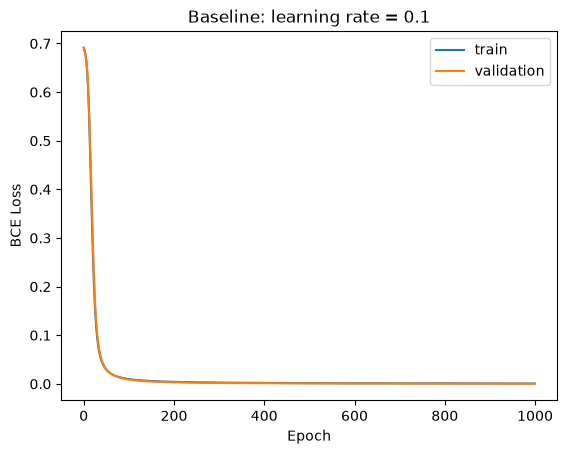

In [81]:
plt.plot(
    baseline_history["train_loss"],
    label="train",
)
plt.plot(
    baseline_history["val_loss"],
    label="validation",
)

plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Baseline: learning rate = 0.1")
plt.legend()
plt.show()

## 학습률 비교 실험

현재 모델에서 차이가 명확히 드러나는 세 조건

* 1e-5: 너무 작음

* 0.1: 적절함

* 10.0: 너무 큼

실행 전 예상

* 1e-5: loss가 거의 줄지 않을 것 같음

* 0.1: 가장 빠르고, 안정적으로 수렴할 것 같음

* 10.0: loss가 크게 튀거나 학습이 실패할 것 같음

In [82]:
learning_rates = [1e-5, 0.1, 10.0]
histories = {}

for learning_rate in learning_rates:
    _, history = train_model(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=learning_rate,
        epochs=1000,
        batch_size=32,
        parameter_seed=42,
        batch_seed=1234,
        weight_scale=0.1,
    )

    histories[learning_rate] = history

    print(f"\nlearning rate = {learning_rate}")
    print(
        "final train loss:",
        history["train_loss"][-1],
    )
    print(
        "final val loss:",
        history["val_loss"][-1],
    )
    print(
        "final val accuracy:",
        history["val_accuracy"][-1],
    )


learning rate = 1e-05
final train loss: 0.6946182685654244
final val loss: 0.693443079417207
final val accuracy: 0.3375

learning rate = 0.1
final train loss: 0.0007275132376927086
final val loss: 0.00035973793669136336
final val accuracy: 1.0

learning rate = 10.0
final train loss: 0.460864334147648
final val loss: 0.5435837852009782
final val accuracy: 0.675


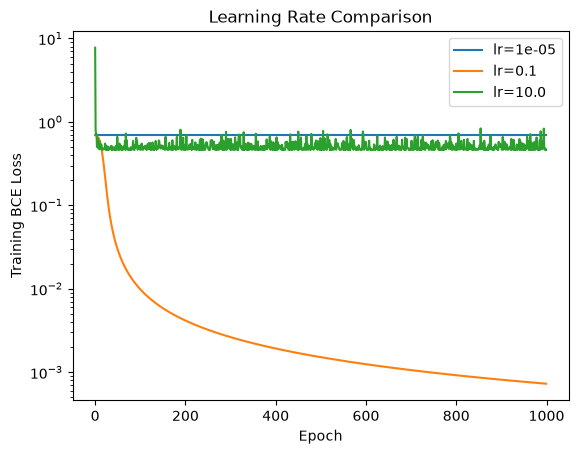

In [83]:
for learning_rate, history in histories.items():
    plt.plot(
        history["train_loss"],
        label=f"lr={learning_rate}",
    )

plt.xlabel("Epoch")
plt.ylabel("Training BCE Loss")
plt.title("Learning Rate Comparison")
plt.yscale("log") # log를 사용하는 이유는, 크기가 매우 다른 손실들을 한 그래프에서 보기 위함
plt.legend()
plt.show()

예상했던 결과대로 나온 것 같음

1. lr = 1e-05는 거의 평평하다

2. lr = 0.1이 가장 안정적으로 감소한다

3. lr = 10.0일때 제대로 학습이 사실상 안된다

### 실험 결과 정리

```lr = 1e-5```: 지나치게 작은 업데이트

초기 gradient norm이 약 0.04엮으므로 업데이트 크기는 대략

$$\eta\lVert\nabla L\rVert
\approx
10^{-5}\times0.04
=
4\times10^{-7}$$

초기 가중치 규모가 0.1인데 한 번에 $10^-7$ 수준만 움직이므로, 1000epoch를 학습해도 변화가 작다

즉, gradient의 방향은 맞지만, 이동거리가 너무 짧음

<br>

```lr = 0.1```: 안정적 수렴

대략적인 업데이트 크기는
$$
10 \times 0.04 = 0.4
$$

초기 가중치보다 충분히 작아서 모델을 망가뜨리지 않고, 학습을 진행시킬만큼은 크다.

<br>

```lr = 10.0```: 업데이트가 가중치 규모를 압도함

대략적인 업데이트 크기는 0.4정도 된다

이는 초기 가중치인 0.1보다 크고, 한 번의 업데이트로 가중치가 기존 값보다 몇 배 크게 바뀔 수 있다. 

이는

* 최적점을 지나침

* mini-batch마다 크게 다른 방향으로 이동

* sigmoid가 포화 영역으로 진입

* 일부 ReLU 뉴런 비활성화

* loss가 진동하거나 높은 값에 머뭄

이러한 특성들을 지니게 된다

즉 학습률 10에서는 gradient에 비해 업데이트 폭이 지나치게 커서 파라미터가 안정적인 하강 경로를 따르지 못하고, loss는 진동하여 수렴하지 않음

<br>

### 실험의 결론

학습률(lr)은 gradient의 방향을 바꾸지 않고 이동거리만 조절한다.

너무 작은 학습률은 올바른 방향으로도 충분히 이동하지 못하고, 너무 큰 학습률은 업데이트가 파라미터 규모를 압도해 안정적 수렴을 방해한다 

물론 그렇다고 0.1만이 늘 좋은 학습률은 아니며, **모델 구조/초기회/데이터 규모/gradient 크기/optimizer에 따라 달라질 수 있다.**

## 가중치 초기화 비교

학습률은 0.1로 고정하고, 초기화만 변경

### 예상치

| 방법 | 가중치 표준편차 | 예상 |
|:------|:--------------:|:-----|
| Zero | $0$ | 뉴런 대칭성 때문에 학습 실패 |
| Small | $0.01$ | 신호와 gradient가 작아 느린 학습 |
| Large | $10$ | 활성값과 gradient가 폭주하거나 sigmoid가 포화됨 |
| Xavier | $\sqrt{\frac{1}{\text{fan-in}}}$ | 신호의 분산을 비교적 안정적으로 유지 |
| He | $\sqrt{\frac{2}{\text{fan-in}}}$ | ReLU에서 활성값의 분산을 유지 |

`fan-in`은 해당 층으로 **들어오는 입력의 개수**

- `W1`: $\text{fan-in}=2$
- `W2`: $\text{fan-in}=8$

In [84]:
def initialize_parameters(
    input_dim=2,
    hidden_dim=8,
    output_dim=1,
    seed=42,
    method="baseline",
    weight_scale=0.1,
):
    rng = np.random.default_rng(seed)

    # 같은 seed에서는 같은 난수 방향을 사용한다.
    base_W1 = rng.standard_normal(
        (input_dim, hidden_dim)
    )
    base_W2 = rng.standard_normal(
        (hidden_dim, output_dim)
    )

    if method == "zero":
        W1 = np.zeros_like(base_W1)
        W2 = np.zeros_like(base_W2)

    elif method == "small":
        W1 = base_W1 * 0.01
        W2 = base_W2 * 0.01

    elif method == "large":
        W1 = base_W1 * 10.0
        W2 = base_W2 * 10.0

    elif method == "xavier":
        W1 = base_W1 * np.sqrt(1 / input_dim)
        W2 = base_W2 * np.sqrt(1 / hidden_dim)

    elif method == "he":
        W1 = base_W1 * np.sqrt(2 / input_dim)
        W2 = base_W2 * np.sqrt(2 / hidden_dim)

    elif method == "baseline":
        W1 = base_W1 * weight_scale
        W2 = base_W2 * weight_scale

    else:
        raise ValueError(
            f"알 수 없는 초기화 방법: {method}"
        ) # 예외처리

    return {
        "W1": W1,
        "b1": np.zeros((1, hidden_dim)),
        "W2": W2,
        "b2": np.zeros((1, output_dim)),
    }

bias는 모두 0으로 둔다

가중치가 서로 다르게 초기화되어 있다면 bias를 0으로 두는 것은 대칭성 문제를 일으키지 않는다

### 초기 상태부터 관찰하기

학습하기 전에 각 초기화가 활성값과 gradient를 어떻게 바꾸는지 확인한다

즉 가중치 W와 Bias b가 뭐로 초기화 해야 하는지, 어떤게 가장 적절한지...

각 초기화 방법이 학습 시작 시 신호와 gradient를 얼마나 잘 전달하는지를 비교하는 것

좋은 초기화는 Z1의 분산이 적절하고, ReLU 활성화 비율이 극단적이지 않으며, gradient의 크기도 너무 작거나 크지 않다

In [85]:
initialization_methods = [
    "zero",
    "small",
    "large",
    "xavier",
    "he",
] # 초기화 방법들

for method in initialization_methods:
    parameters = initialize_parameters(
        seed=42,
        method=method,
    ) # 파라미터 초기화

    Y_hat, cache = forward(X_train, parameters)
    loss = compute_loss(Y_hat, y_train)

    gradients = backward(
        X_train,
        y_train,
        parameters,
        cache,
    )

    # 초기화 상태 분석

    print(f"\n[{method}]")
    print("initial loss:", loss) # 초기 가중치 손실
    print("Z1 std:", cache["Z1"].std()) # Z1의 표준편차 
    print(
        "ReLU active ratio:",
        np.mean(cache["A1"] > 0), # ReLU 활성화 비율
    )
    print(
        "Y_hat range:",
        Y_hat.min(),
        Y_hat.max(),
    ) # 예측 값의 범위
    print(
        "dW1 norm:",
        np.linalg.norm(gradients["dW1"]),
    ) # dW1의 크기
    print(
        "dW2 norm:",
        np.linalg.norm(gradients["dW2"]),
    ) # dW2의 크기


[zero]
initial loss: 0.6931471805599453
Z1 std: 0.0
ReLU active ratio: 0.0
Y_hat range: 0.5 0.5
dW1 norm: 0.0
dW2 norm: 0.0

[small]
initial loss: 0.693165175568139
Z1 std: 0.012935895844970879
ReLU active ratio: 0.5015625
Y_hat range: 0.4999081142635365 0.5000837419432752
dW1 norm: 0.004227095754467886
dW2 norm: 0.004322621601886501

[large]
initial loss: 15.849024309802719
Z1 std: 12.935895844970878
ReLU active ratio: 0.5015625
Y_hat range: 1.928749847963918e-22 1.0
dW1 norm: 8.05821229202014
dW2 norm: 9.82146610734459

[xavier]
initial loss: 0.7668667282271355
Z1 std: 0.9147059672701793
ReLU active ratio: 0.5015625
Y_hat range: 0.28519076921794245 0.6979214421702608
dW1 norm: 0.17662630244564378
dW2 norm: 0.37029917244456645

[he]
initial loss: 0.8930146099876136
Z1 std: 1.2935895844970877
ReLU active ratio: 0.5015625
Y_hat range: 0.13732178930635508 0.8422199037984959
dW1 norm: 0.2895567984624946
dW2 norm: 0.6401181918947576


### 결과 관찰 방법

* inital loss: 처음부터 얼마나 틀렸는가? -> 너무 크지 않아야함

* Z1 std: 은닉층 입력(Z1)의 분산 -> 너무 작지도 크지도 않아야함

* ReLU activae ratio: 살아있는 (ReLU>0) 뉴런 비율 -> 약 50% 정도가 적절

* Y_hat range: 예측값의 범위 -> 0이나 1에 치우치지 않아야함

* dW1 norm, dW2 norm: gradient의 크기 -> 너무 작거나 너무 크지 않아야함

즉, 좋은 초기화는 은닉층의 활성값과 gradient가 층을 지나도 너무 작아지거나 커지지 않도록 만드는 것이다

Xavier와 He 초기화가 널리 사용되는 이유도 바로 이 균형을 맞춰 주기 때문이다

In [86]:
def train_model(
    X_train,
    y_train,
    X_val,
    y_val,
    learning_rate,
    epochs=1000,
    batch_size=32,
    parameter_seed=42,
    batch_seed=1234,
    initialization="baseline",
    weight_scale=0.1,
):
    parameters = initialize_parameters(
        seed=parameter_seed,
        method=initialization,
        weight_scale=weight_scale,
    )

    batch_rng = np.random.default_rng(batch_seed)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
    }

    N = X_train.shape[0]

    for epoch in range(epochs):
        # epoch마다 데이터 순서를 새로 섞는다.
        shuffled_indices = batch_rng.permutation(N)

        for start in range(0, N, batch_size):
            end = start + batch_size
            batch_indices = shuffled_indices[start:end]

            X_batch = X_train[batch_indices]
            y_batch = y_train[batch_indices]

            # 한 번의 mini-batch 학습
            Y_hat, cache = forward(X_batch, parameters)
            gradients = backward(
                X_batch,
                y_batch,
                parameters,
                cache,
            )

            parameters = update_parameters(
                parameters,
                gradients,
                learning_rate,
            )

        # epoch 종료 후 전체 데이터에서 평가
        train_Y_hat, _ = forward(X_train, parameters)
        val_Y_hat, _ = forward(X_val, parameters)

        history["train_loss"].append(
            compute_loss(train_Y_hat, y_train)
        )
        history["val_loss"].append(
            compute_loss(val_Y_hat, y_val)
        )
        history["train_accuracy"].append(
            compute_accuracy(train_Y_hat, y_train)
        )
        history["val_accuracy"].append(
            compute_accuracy(val_Y_hat, y_val)
        )

    return parameters, history

In [87]:
initialization_histories = {}

for method in initialization_methods:
    _, history = train_model(
        X_train,
        y_train,
        X_val,
        y_val,
        learning_rate=0.1,
        epochs=1000,
        batch_size=32,
        parameter_seed=42,
        batch_seed=1234,
        initialization=method,
    )

    initialization_histories[method] = history

    print(f"\n[{method}]")
    print(
        "final train loss:",
        history["train_loss"][-1],
    )
    print(
        "final val loss:",
        history["val_loss"][-1],
    )
    print(
        "final val accuracy:",
        history["val_accuracy"][-1],
    )


[zero]
final train loss: 0.6929718868151915
final val loss: 0.6946363453586489
final val accuracy: 0.4625

[small]
final train loss: 0.0007374686799396665
final val loss: 0.0003679382679499173
final val accuracy: 1.0

[large]
final train loss: 3.721014465939888e-05
final val loss: 0.004235210337419791
final val accuracy: 1.0

[xavier]
final train loss: 0.0007123064621567053
final val loss: 0.0003700621653266418
final val accuracy: 1.0

[he]
final train loss: 0.0007028595429931832
final val loss: 0.00036853486853310796
final val accuracy: 1.0


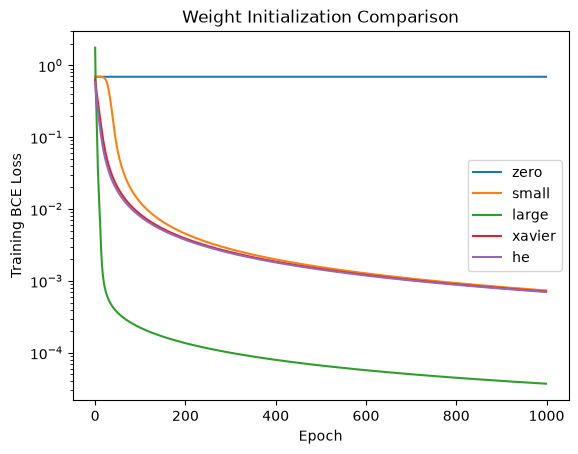

In [88]:
for method, history in initialization_histories.items():
    plt.plot(
        history["train_loss"],
        label=method,
    )

plt.xlabel("Epoch")
plt.ylabel("Training BCE Loss")
plt.title("Weight Initialization Comparison")
plt.yscale("log")
plt.legend()
plt.show()

### 그래프 분석

zero가 평평한 이유는, 애초애 모든 gradient 경로가 처음부터 막히기 때문이다

초기에 $$ W1 = 0, W2 = 0$$

이기에 뒤따라오는 모든 값들도 자연스럽게 0이 된다

### 결론

Large 초기화는 이번 단순한 문제에서는 큰 gradient 덕분에 빠르게 loss를 낮췄지만,
 
초기 sigmoid 포화와 큰 gradient를 유발했으며 검증 loss도 상대적으로 높았다. 

Small 초기화는 작은 gradient 때문에 초반 학습이 느렸지만 충분한 epoch 후 수렴했다. 

Xavier와 He는 극단적인 활성값이나 gradient 없이 안정적으로 수렴했다.

In [89]:
for method, history in initialization_histories.items():
    losses = np.array(history["train_loss"])
    reached = np.where(losses < 0.01)[0]

    first_epoch = (
        reached[0] + 1
        if len(reached) > 0
        else None
    )

    print(method, first_epoch)

zero None
small 115
large 11
xavier 88
he 82


zero: 학습 경로가 막혀 기준에 도달하지 못함

small: gradient가 작아 가장 느림

Xavier, He: 안정적이고 비슷한 속도

large: 이번 seed에서는 큰 gradient로 가장 빠르게 기준 통과

### 초기화 Seed별 안정성 테스트

In [90]:
seeds = range(10)
threshold = 0.01

for method in initialization_methods:
    reached_epochs = []
    final_val_losses = []
    final_val_accuracies = []

    for seed in seeds:
        _, history = train_model(
            X_train,
            y_train,
            X_val,
            y_val,
            learning_rate=0.1,
            epochs=300,
            batch_size=32,
            parameter_seed=seed,
            batch_seed=1234,
            initialization=method,
        )

        losses = np.array(history["train_loss"])
        reached = np.where(losses < threshold)[0]

        if len(reached) > 0:
            reached_epochs.append(reached[0] + 1)

        final_val_losses.append(
            history["val_loss"][-1]
        )
        final_val_accuracies.append(
            history["val_accuracy"][-1]
        )

    success_count = len(reached_epochs)

    print(f"\n[{method}]")
    print(f"threshold success: {success_count}/10")

    if reached_epochs:
        print(
            "median epoch:",
            np.median(reached_epochs),
        )

    print(
        "median val loss:",
        np.median(final_val_losses),
    )
    print(
        "minimum val accuracy:",
        np.min(final_val_accuracies),
    )


[zero]
threshold success: 0/10
median val loss: 0.6949972362147411
minimum val accuracy: 0.4625

[small]
threshold success: 8/10
median epoch: 251.0
median val loss: 0.007369464701532307
minimum val accuracy: 0.7875

[large]
threshold success: 8/10
median epoch: 46.0
median val loss: 0.004461111867162377
minimum val accuracy: 0.975

[xavier]
threshold success: 9/10
median epoch: 220.0
median val loss: 0.005859452891885991
minimum val accuracy: 0.7875

[he]
threshold success: 9/10
median epoch: 171.0
median val loss: 0.004392646440922602
minimum val accuracy: 0.7875


### 결과 분석

음.. 특이하게도 Large가 상당히 경쟁력이 있다.

이론에 끼워맞추기 보다, 결과에 맞춘 해석을 하자면 데이터가 단순해서 가장 잘 뽑힌 것 같기도 하다

다만 성공률은 다른 것보다 낮은 단점도 존재한다

### 최종 결론 

단일 은닉층의 단순한 XOR 문제에서는 large 초기화가 큰 gradient와 가파른 초기 결정 경계 덕분에 가장 빠르게 학습했다.

그러나 성공률은 Xavier·He보다 조금 낮았다. 

He 초기화는 가장 빠르지는 않았지만 높은 성공률과 가장 낮은 중앙 검증 손실을 보여 속도와 안정성의 균형이 좋았다.

## 최종 점검

In [91]:
import pandas as pd


def first_epoch_below(losses, threshold=0.01):
    reached = np.where(
        np.array(losses) < threshold
    )[0]

    return (
        int(reached[0] + 1)
        if len(reached) > 0
        else None
    )

### 학습률 비교표

In [92]:
learning_rate_rows = []

for learning_rate, history in histories.items():
    learning_rate_rows.append({
        "learning_rate": learning_rate,
        "epoch_1_train_loss":
            history["train_loss"][0],
        "final_train_loss":
            history["train_loss"][-1],
        "final_val_loss":
            history["val_loss"][-1],
        "final_val_accuracy":
            history["val_accuracy"][-1],
        "epoch_to_loss_0.01":
            first_epoch_below(
                history["train_loss"]
            ),
    })

learning_rate_summary = pd.DataFrame(
    learning_rate_rows
)

display(learning_rate_summary)

,learning_rate,epoch_1_train_loss,final_train_loss,final_val_loss,final_val_accuracy,epoch_to_loss_0.01
0,0.00001,0.694993,0.694618,0.693443,0.3375,NaN
1,0.10000,0.691347,0.000728,0.000360,1.0000,100.0
2,10.00000,7.749066,0.460864,0.543584,0.6750,NaN


### 초기화 비교표

In [93]:
initialization_rows = []

for method, history in initialization_histories.items():
    initialization_rows.append({
        "initialization": method,
        "final_train_loss":
            history["train_loss"][-1],
        "final_val_loss":
            history["val_loss"][-1],
        "final_val_accuracy":
            history["val_accuracy"][-1],
        "epoch_to_loss_0.01":
            first_epoch_below(
                history["train_loss"]
            ),
    })

initialization_summary = pd.DataFrame(
    initialization_rows
)

display(initialization_summary)

,initialization,final_train_loss,final_val_loss,final_val_accuracy,epoch_to_loss_0.01
0,zero,0.692972,0.694636,0.4625,NaN
1,small,0.000737,0.000368,1.0000,115.0
2,large,0.000037,0.004235,1.0000,11.0
3,xavier,0.000712,0.000370,1.0000,88.0
4,he,0.000703,0.000369,1.0000,82.0


### 다중 seed 결과표

In [94]:
seed_summary = pd.DataFrame([
    {
        "initialization": "zero",
        "success_rate": "0/10",
        "median_epoch": None,
        "median_val_loss": 0.694997,
        "minimum_val_accuracy": 0.4625,
    },
    {
        "initialization": "small",
        "success_rate": "8/10",
        "median_epoch": 251,
        "median_val_loss": 0.007369,
        "minimum_val_accuracy": 0.7875,
    },
    {
        "initialization": "large",
        "success_rate": "8/10",
        "median_epoch": 46,
        "median_val_loss": 0.004461,
        "minimum_val_accuracy": 0.975,
    },
    {
        "initialization": "xavier",
        "success_rate": "9/10",
        "median_epoch": 220,
        "median_val_loss": 0.005859,
        "minimum_val_accuracy": 0.7875,
    },
    {
        "initialization": "he",
        "success_rate": "9/10",
        "median_epoch": 171,
        "median_val_loss": 0.004393,
        "minimum_val_accuracy": 0.7875,
    },
])

display(seed_summary)

,initialization,success_rate,median_epoch,median_val_loss,minimum_val_accuracy
0,zero,0/10,NaN,0.694997,0.4625
1,small,8/10,251.0,0.007369,0.7875
2,large,8/10,46.0,0.004461,0.9750
3,xavier,9/10,220.0,0.005859,0.7875
4,he,9/10,171.0,0.004393,0.7875


In [95]:
from pathlib import Path

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

learning_rate_summary.to_csv(
    results_dir / "learning_rate_summary.csv",
    index=False,
)

initialization_summary.to_csv(
    results_dir / "initialization_summary.csv",
    index=False,
)

seed_summary.to_csv(
    results_dir / "initialization_seed_summary.csv",
    index=False,
)

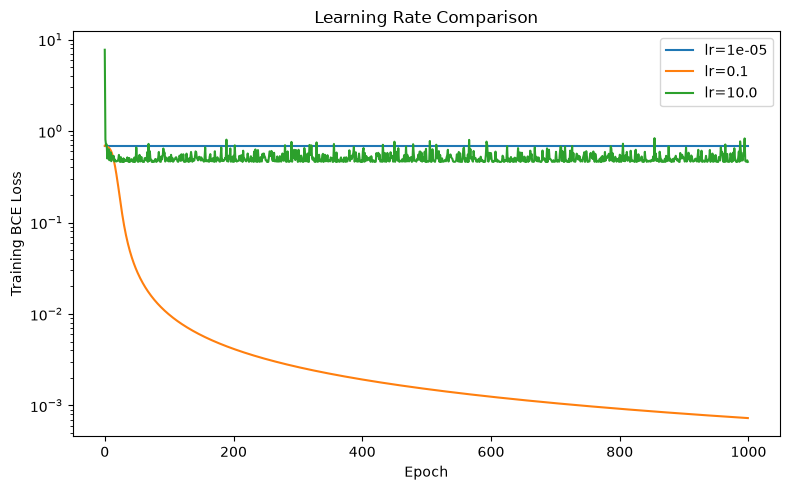

In [96]:
plt.figure(figsize=(8, 5))

for learning_rate, history in histories.items():
    plt.plot(
        history["train_loss"],
        label=f"lr={learning_rate}",
    )

plt.xlabel("Epoch")
plt.ylabel("Training BCE Loss")
plt.title("Learning Rate Comparison")
plt.yscale("log")
plt.legend()
plt.tight_layout()

plt.savefig(
    results_dir / "learning_rate_comparison.png",
    dpi=200,
)

plt.show()

## 실험 결론

### 학습률 비교

학습률은 gradient의 방향이 아니라 한 번의 업데이트에서 이동하는 크기를 결정한다. 

`lr=1e-5`에서는 업데이트가 지나치게 작아 1,000 epoch 동안 loss가 거의 감소하지 않았다. 

`lr=0.1`에서는 충분한 이동 거리와 안정성이 균형을 이루어 loss가 빠르고 안정적으로 수렴했다. 

반면 `lr=10.0`에서는 한 번의 업데이트가 초기 파라미터 규모를 압도하면서 mini-batch마다 크게 흔들렸고, 안정적인 해에 수렴하지 못했다.

따라서 이번 데이터와 모델에서는 `lr=0.1`이 가장 적절했다. 

다만 적절한 학습률은 모델 구조, 초기화, 데이터 및 optimizer에 따라 달라지므로 일반적인 최적값으로 해석할 수는 없다.

### 초기화 비교

Zero 초기화에서는 모든 은닉 뉴런이 같은 상태에서 시작했다. 

`A1`과 가중치 gradient가 모두 0이 되면서 학습 경로가 막혔고, loss가 약 0.693에서 감소하지 않았다.

Small 초기화는 초기 gradient가 매우 작아 다른 초기화보다 초반 학습이 느렸다. 

하지만 얕고 단순한 문제였으며 충분한 epoch를 제공했기 때문에 최종적으로는 좋은 해에 도달했다.

Large 초기화는 초기 활성값과 gradient가 매우 컸지만, 이번 단일 은닉층 XOR 문제에서는 큰 업데이트가 빠른 학습으로 연결됐다. 

단일 seed에서 loss 0.01에 11 epoch 만에 도달했고, 10개 seed 비교에서도 중앙값 46 epoch로 가장 빨랐다. 

그러나 성공률은 8/10으로 Xavier와 He의 9/10보다 낮았다. 따라서 빠른 한 번의 결과가 항상 안정적인 초기화를 의미하지는 않는다.

Xavier와 He 초기화는 극단적인 활성값이나 gradient 없이 안정적으로 학습했다. 

특히 He 초기화는 9/10의 성공률, 중앙 171 epoch, 가장 낮은 중앙 검증 loss를 기록해 속도와 안정성 사이에서 좋은 균형을 보였다.

### 최종 결론

학습률과 초기화는 독립적인 설정이 아니라 gradient와 활성값의 크기를 함께 결정한다. 

좋은 학습 설정은 단순히 가장 빠른 한 번의 결과가 아니라, 여러 seed에서의 성공률·수렴 속도·검증 성능을 함께 기준으로 선택해야 한다.